# 02 - Data Preprocessing Pipeline

**Author:** Bharath Krishna  
**Date:** May 24, 2026  
**Project:** Dr. Friend - AI Healthcare Guidance

## Overview
This notebook demonstrates the complete preprocessing pipeline:gi
1. Loading data
2. Handling missing values
3. Feature engineering
4. Encoding categorical variables
5. Train/test split
6. Feature scaling
7. Class balancing with SMOTE

In [34]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

In [58]:
# Add project root
project_root = Path.cwd().parent
sys.path.append(str(project_root))

# Add ml directory
ml_dir = project_root / 'ml'
sys.path.append(str(ml_dir))

print("Path configured")
print(f"Project root: {project_root}")
print(f"ML directory: {ml_dir}")

Path configured
Project root: c:\Projects\dr-friend
ML directory: c:\Projects\dr-friend\ml


In [59]:
# Import config first
import config

# Then import preprocessing functions
from ml.preprocess import (
    load_data,
    handle_missing_values,
    engineer_features,
    encode_categorical,
    split_data,
    scale_features,
    apply_smote
)

# Import config variables we need
from config import *

print("Functions imported successfully")

Functions imported successfully


In [38]:
# Load dataset
df = load_data()

# Display first few rows
df.head()

LOADING DATASET
Dataset loaded: 3000 rows, 55 columns
Target variable: disease
Classes: 16


,row_id,age,gender,height_cm,weight_kg,bmi,temperature_c,heart_rate_bpm,systolic_bp,diastolic_bp,...,sym_excessive_thirst,sym_frequent_urination,sym_unexplained_weight_loss,sym_excessive_sweating,sym_joint_pain,sym_muscle_aches,sym_back_pain,disease,broad_category,comorbidity
0,0,48,Female,152.9,48.8,20.9,39.9,62,97.0,NaN,...,0,0,0,1,0,0,0,Typhoid,Infectious,NaN
1,1,42,Male,167.9,62.5,22.2,37.4,94,159.0,84.0,...,1,1,1,1,0,0,0,Type 2 Diabetes,Metabolic,NaN
2,2,34,Female,148.8,67.7,30.6,39.7,118,133.0,55.0,...,0,0,0,0,0,0,1,Pneumonia,Respiratory,NaN
3,3,37,Female,152.6,57.0,24.5,37.6,107,114.0,60.0,...,0,0,0,0,1,1,0,COVID-19,Respiratory,NaN
4,4,25,Male,167.5,99.9,35.6,37.6,125,133.0,79.0,...,0,0,0,0,0,0,0,Anxiety Attack,Neurological,NaN


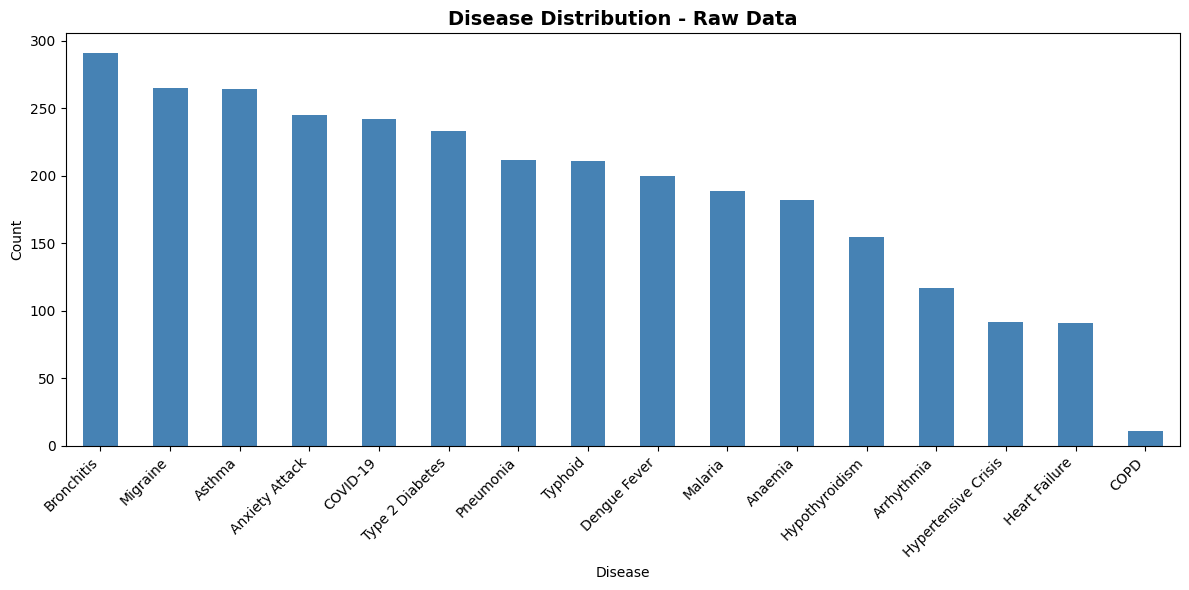

In [47]:
# Class distribution
plt.figure(figsize=(12, 6))
df['disease'].value_counts().sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Disease Distribution - Raw Data', fontsize=14, fontweight='bold')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [39]:
#checking for missing values
df.isna().sum()

row_id                            0
age                               0
gender                            0
height_cm                         0
weight_kg                         0
bmi                               0
temperature_c                     0
heart_rate_bpm                    0
systolic_bp                     240
diastolic_bp                    258
pulse_pressure                  240
spo2_percent                      0
respiratory_rate                646
blood_glucose_mgdl              478
symptom_duration_days             0
sym_cough                         0
sym_productive_cough              0
sym_shortness_of_breath           0
sym_wheezing                      0
sym_chest_tightness               0
sym_chest_pain                    0
sym_nasal_congestion              0
sym_sore_throat                   0
sym_fever                         0
sym_chills                        0
sym_fatigue                       0
sym_weakness                      0
sym_night_sweats            

There are 4k+ missing values in the dataset

In [41]:
#filling the missing values with median for numerical columns and 'None' for categorical column
df=handle_missing_values(df)


HANDLING MISSING VALUES
Missing values before: 4563
 systolic_bp: Filled 0 with median 117.00
 diastolic_bp: Filled 0 with median 75.00
 pulse_pressure: Filled 0 with median 43.00
 respiratory_rate: Filled 0 with median 18.00
 blood_glucose_mgdl: Filled 0 with median 93.00
 comorbidity: Filled with 'none'

Missing values after: 0


c:\Projects\dr-friend\ml\preprocess.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
c:\Projects\dr-friend\ml\preprocess.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [43]:
df=engineer_features(df)


FEATURE ENGINEERING
 Created age_group
 Created fever_category
 Created symptom_count (avg: 9.14)
 Created vital_risk_score (avg: 1.11)


In [44]:
df['age_group'].value_counts()

age_group
adult         1694
middle_age     639
child          490
elderly        177
Name: count, dtype: int64

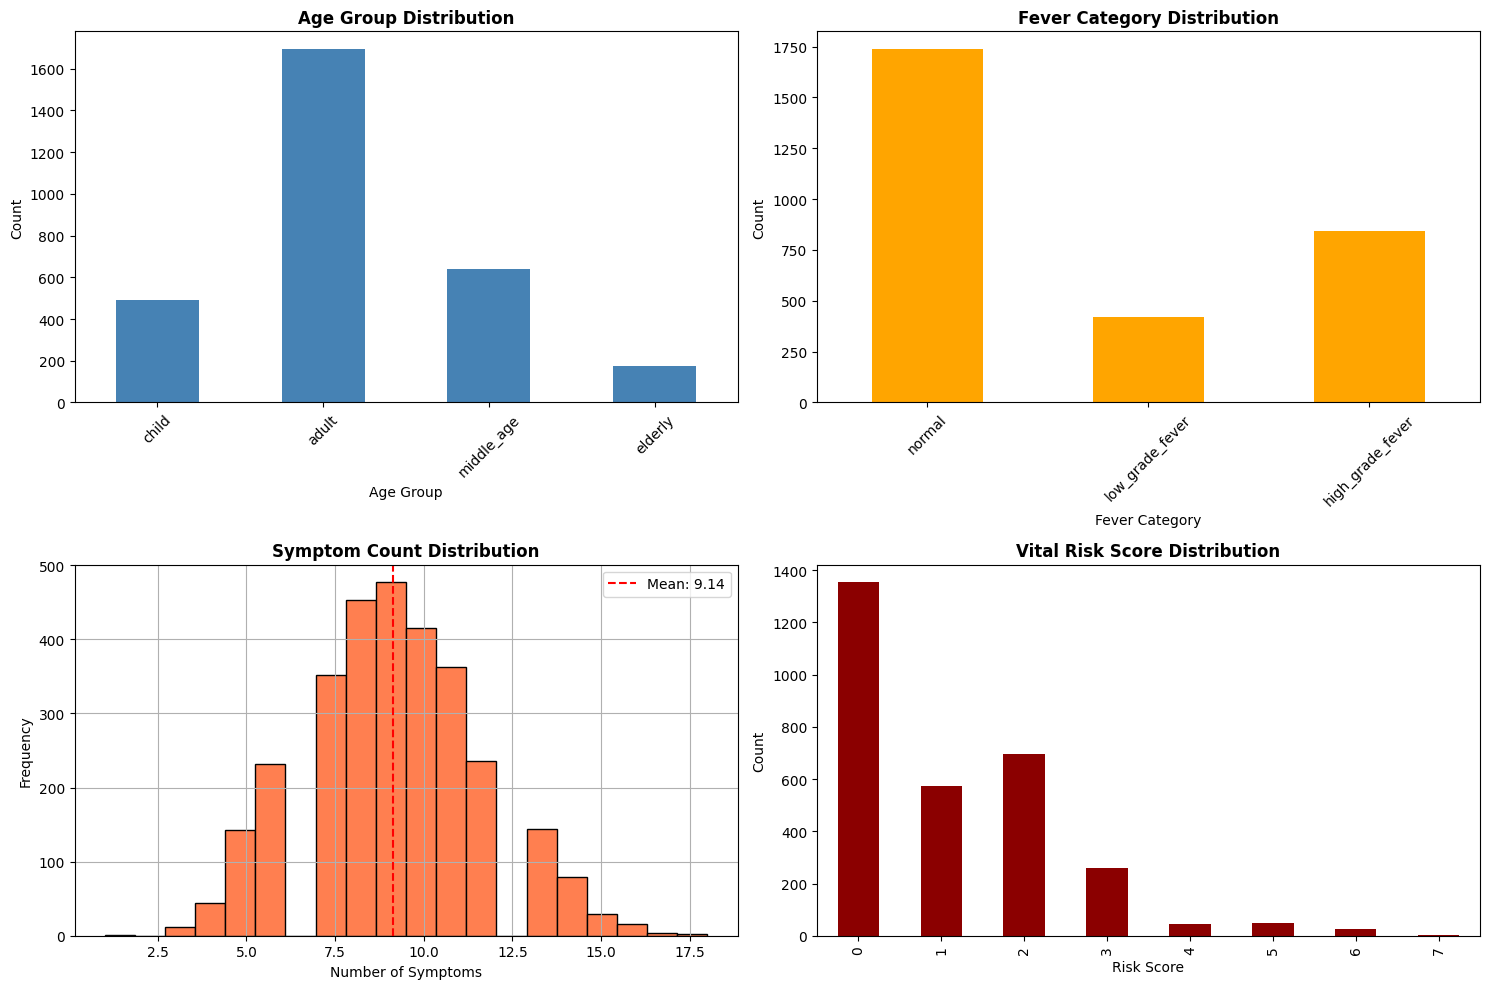

In [45]:
#visualising newly engineered features
# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Age Group (top-left)
df['age_group'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Age Group Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Age Group')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Fever Category (top-right)
df['fever_category'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Fever Category Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Fever Category')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Symptom Count (bottom-left)
df['symptom_count'].hist(bins=20, ax=axes[1, 0], color='coral', edgecolor='black')
axes[1, 0].set_title('Symptom Count Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Number of Symptoms')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(df['symptom_count'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {df["symptom_count"].mean():.2f}')
axes[1, 0].legend()

# 4. Vital Risk Score (bottom-right)
df['vital_risk_score'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], color='darkred')
axes[1, 1].set_title('Vital Risk Score Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Risk Score')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [49]:
df, le_target = encode_categorical(df)
print(f"Encoding complete. Total features now: {len(df.columns)}")


ENCODING CATEGORICAL VARIABLES
 Target encoded: 16 classes
  Final feature count: 80
Encoding complete. Total features now: 80


In [50]:
X_train, X_test, y_train, y_test = split_data(df)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


TRAIN/TEST SPLIT
  Train set: 2400 samples
  Test set: 600 samples
  Features: 79
Train set: (2400, 79)
Test set: (600, 79)



FEATURE SCALING
  Features scaled (mean=0, std=1)


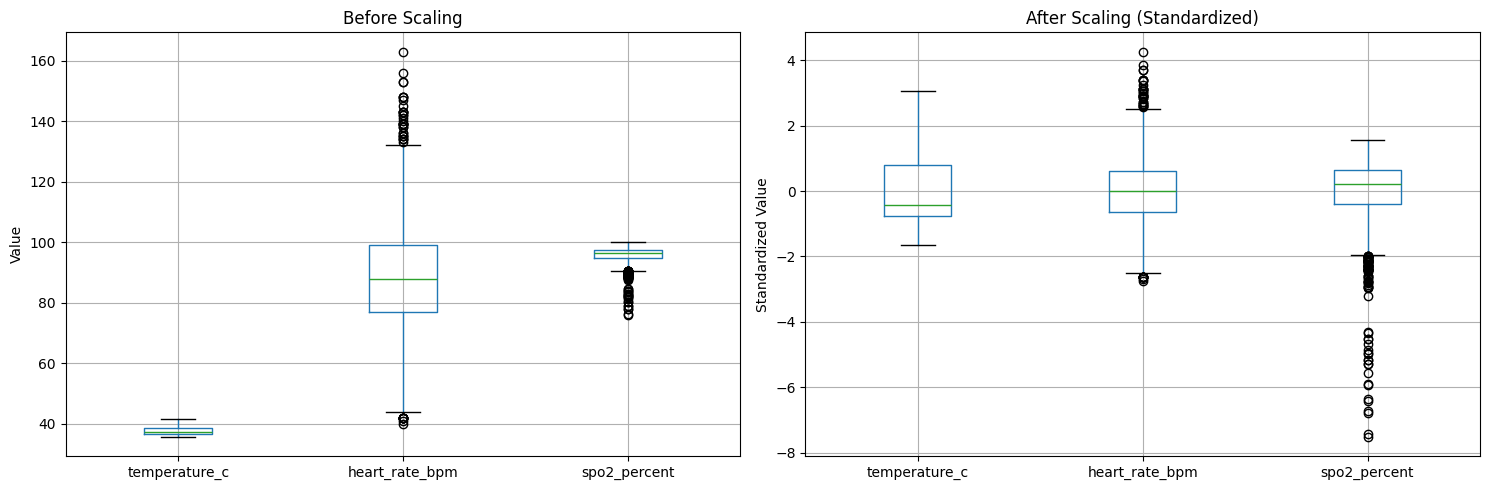

In [51]:
#feature scaling
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

# Visualize scaling effect (before/after)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Before scaling
X_train[['temperature_c', 'heart_rate_bpm', 'spo2_percent']].boxplot(ax=axes[0])
axes[0].set_title('Before Scaling')
axes[0].set_ylabel('Value')

# After scaling
X_train_scaled[['temperature_c', 'heart_rate_bpm', 'spo2_percent']].boxplot(ax=axes[1])
axes[1].set_title('After Scaling (Standardized)')
axes[1].set_ylabel('Standardized Value')

plt.tight_layout()
plt.show()

Class distribution BEFORE SMOTE:
disease
0     145
1     196
2      94
3     211
4     233
5       9
6     194
7     160
8      73
9      73
10    124
11    151
12    212
13    170
14    186
15    169
Name: count, dtype: int64

Total samples: 2400

APPLYING SMOTE
Class distribution before SMOTE:
disease
0     145
1     196
2      94
3     211
4     233
5       9
6     194
7     160
8      73
9      73
10    124
11    151
12    212
13    170
14    186
15    169
Name: count, dtype: int64

Class distribution after SMOTE:
disease
0     233
1     233
2     233
3     233
4     233
5     233
6     233
7     233
8     233
9     233
10    233
11    233
12    233
13    233
14    233
15    233
Name: count, dtype: int64

  SMOTE applied
  Training samples: 2400 → 3728

Class distribution AFTER SMOTE:
disease
0     233
1     233
2     233
3     233
4     233
5     233
6     233
7     233
8     233
9     233
10    233
11    233
12    233
13    233
14    233
15    233
Name: count, dtype: int64

Total

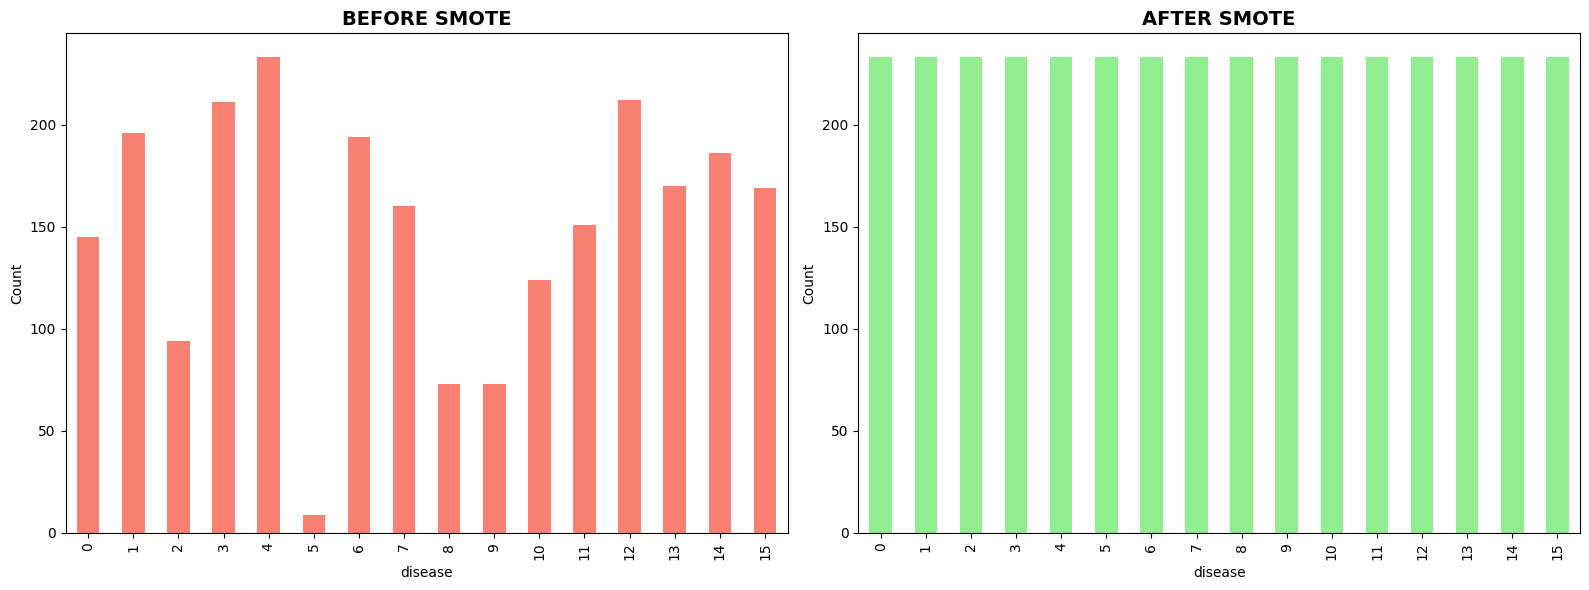

SMOTE applied - all classes balanced!


In [ ]:

# ============================================================================
# CLASS BALANCING WITH SMOTE
# ============================================================================

# Show BEFORE
print("Class distribution BEFORE SMOTE:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nTotal samples: {len(y_train)}")

# Call the function from preprocess.py
X_train_resampled, y_train_resampled = apply_smote(X_train_scaled, y_train)

# Show AFTER
print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_resampled).value_counts().sort_index())
print(f"\nTotal samples: {len(y_train_resampled)}")

# Visualize: Before vs After
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# BEFORE
pd.Series(y_train).value_counts().sort_index().plot(kind='bar', ax=ax1, color='salmon')
ax1.set_title('BEFORE SMOTE', fontsize=14, fontweight='bold')
ax1.set_ylabel('Count')

# AFTER
pd.Series(y_train_resampled).value_counts().sort_index().plot(kind='bar', ax=ax2, color='lightgreen')
ax2.set_title('AFTER SMOTE', fontsize=14, fontweight='bold')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

print("SMOTE applied - all classes balanced!")

In [60]:
print("=" * 80)
print("PREPROCESSING PIPELINE COMPLETE")
print("=" * 80)

print(f"\n Final Shapes:")
print(f"   X_train: {X_train_resampled.shape}")
print(f"   X_test: {X_test_scaled.shape}")
print(f"   y_train: {y_train_resampled.shape}")
print(f"   y_test: {y_test.shape}")

print(f"\n Data ready for model training!")

PREPROCESSING PIPELINE COMPLETE

 Final Shapes:
   X_train: (3728, 79)
   X_test: (600, 79)
   y_train: (3728,)
   y_test: (600,)

 Data ready for model training!
